# CLIP Scan Demo
Scan a single video at 1fps, plot the octopus presence score over time, and identify segments to keep.

In [ ]:
import sys
import os
import time
import logging
sys.path.append('..')
os.chdir('..')  # run from project root so data/ paths resolve correctly

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from pathlib import Path

from phase2.scanner import load_clip, scan_video, save_scores, detect_segments

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(name)s: %(message)s',
    datefmt='%H:%M:%S',
)

## 1. Pick a video and load CLIP

In [2]:
# list available videos
video_dir = Path('../data/videos')
videos = sorted(video_dir.glob('*.mp4'))
for v in videos:
    print(v.name)

Hwji93BVjnI.mp4
LITlLW9bYNs.mp4
LNEaa_cNf9M.mp4
TFzpC_e44Tg.mp4
abRPaXgJGQg.mp4
ebeNeQFUMa0.mp4
lRrkaLTVHrs.mp4
oSyEZAm8nb8.mp4
qnMxd3s6u-c.mp4
tmJtd9BLCuc.mp4


In [3]:
VIDEO_PATH = '../data/videos/LNEaa_cNf9M.mp4'  # change to any video
VIDEO_ID   = Path(VIDEO_PATH).stem

model, processor, text_features, device = load_clip()
print(f'Device: {device}')

Device: cpu


## 2. Scan the video

In [ ]:
t0 = time.perf_counter()

timestamps, scores = scan_video(VIDEO_PATH, model, processor, text_features, device)
save_scores(VIDEO_ID, timestamps, scores)

elapsed = time.perf_counter() - t0
video_duration = float(timestamps[-1]) + 1.0

print(f"\nScanned   : {len(scores)} seconds of video")
print(f"Wall time : {elapsed:.1f}s")
print(f"Realtime  : {video_duration / elapsed:.1f}x  ({'faster' if video_duration > elapsed else 'slower'} than realtime)")
print(f"Per frame : {elapsed / len(scores) * 1000:.0f}ms/frame")
print(f"Score range: {scores.min():.3f} – {scores.max():.3f}  |  mean: {scores.mean():.3f}")

## 3. Score timeline

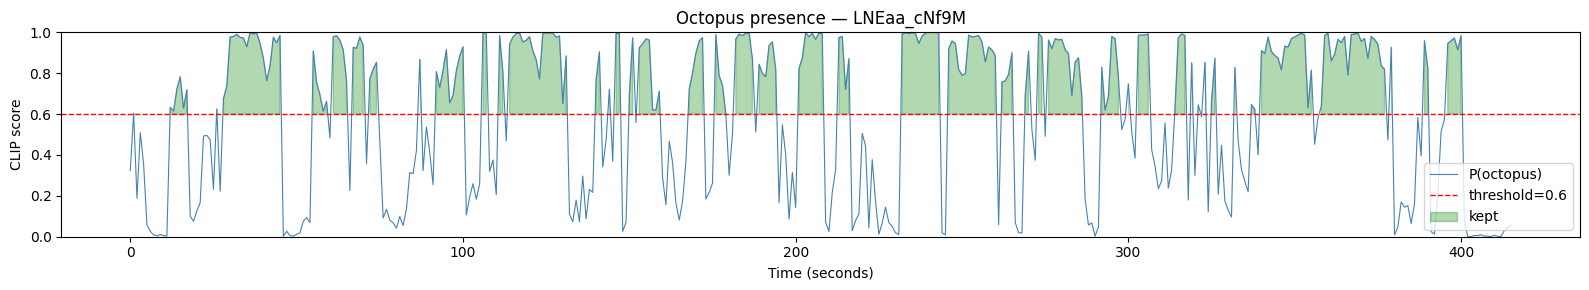

In [5]:
THRESHOLD = 0.6

fig, ax = plt.subplots(figsize=(16, 3))
ax.plot(timestamps, scores, color='steelblue', linewidth=0.8, label='P(octopus)')
ax.axhline(THRESHOLD, color='red', linestyle='--', linewidth=1, label=f'threshold={THRESHOLD}')
ax.fill_between(timestamps, scores, THRESHOLD,
                where=(scores >= THRESHOLD), alpha=0.3, color='green', label='kept')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('CLIP score')
ax.set_title(f'Octopus presence — {VIDEO_ID}')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 4. Detect segments

In [6]:
segments = detect_segments(timestamps, scores, threshold=THRESHOLD, min_duration=5.0)
print(f'Found {len(segments)} segments above threshold (≥5s):')
for i, (start, end) in enumerate(segments):
    print(f'  [{i:02d}]  {start:6.1f}s → {end:6.1f}s  ({end-start:.1f}s)')

Found 18 segments above threshold (≥5s):
  [00]    12.0s →   18.0s  (6.0s)
  [01]    28.0s →   46.0s  (18.0s)
  [02]    55.0s →   60.0s  (5.0s)
  [03]    61.0s →   66.0s  (5.0s)
  [04]    92.0s →  101.0s  (9.0s)
  [05]   114.0s →  132.0s  (18.0s)
  [06]   153.0s →  160.0s  (7.0s)
  [07]   168.0s →  173.0s  (5.0s)
  [08]   182.0s →  188.0s  (6.0s)
  [09]   189.0s →  195.0s  (6.0s)
  [10]   201.0s →  209.0s  (8.0s)
  [11]   232.0s →  244.0s  (12.0s)
  [12]   246.0s →  261.0s  (15.0s)
  [13]   276.0s →  287.0s  (11.0s)
  [14]   292.0s →  298.0s  (6.0s)
  [15]   340.0s →  356.0s  (16.0s)
  [16]   358.0s →  378.0s  (20.0s)
  [17]   396.0s →  401.0s  (5.0s)


## 5. Inspect frames at key score levels
Shows one frame from: high-score segments, borderline, and low-score (no octopus).

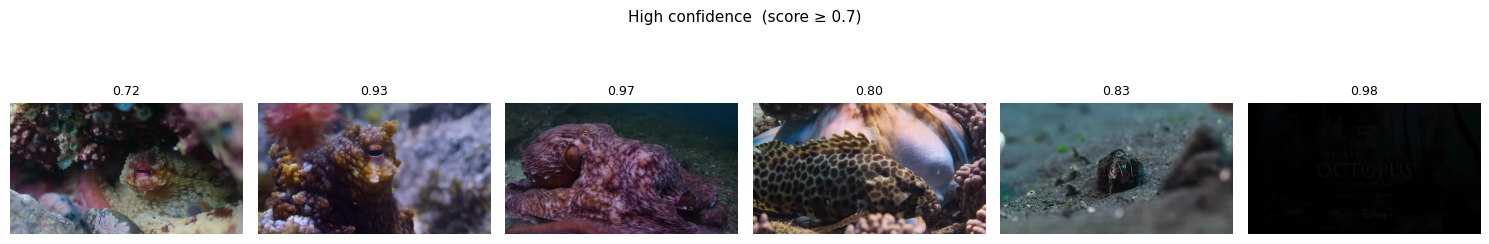

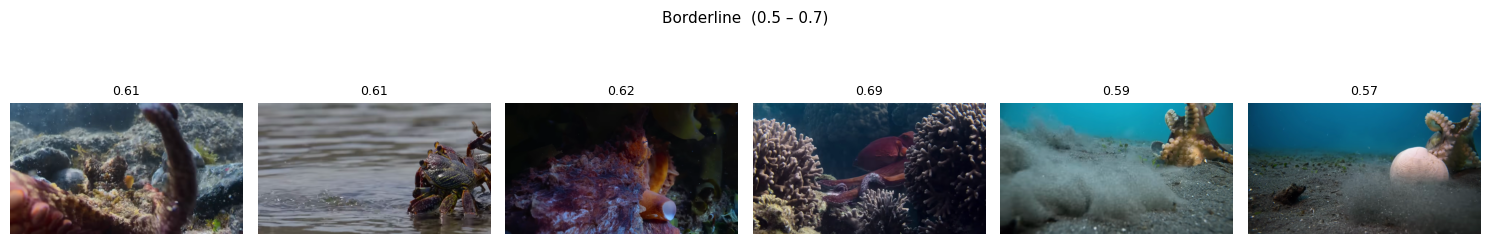

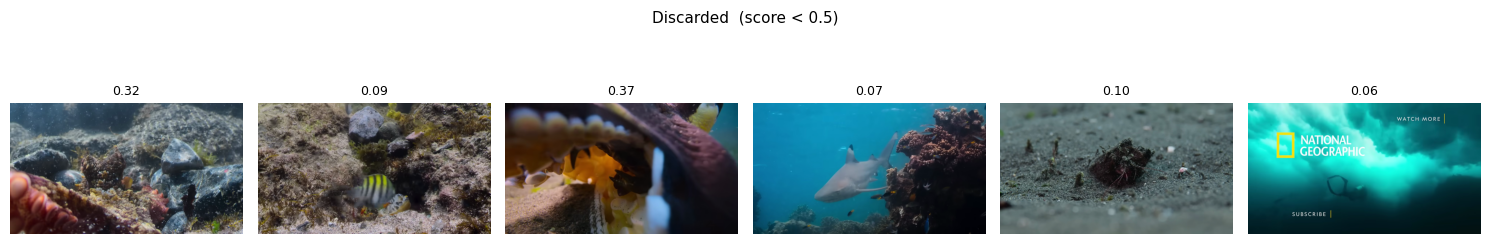

In [7]:
def grab_frame(video_path, timestamp_sec):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(timestamp_sec * fps))
    ret, frame = cap.read()
    cap.release()
    if ret:
        return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    return None

def show_samples(label, mask, n=6):
    idxs = np.where(mask)[0]
    if len(idxs) == 0:
        print(f'No samples for: {label}')
        return
    # pick evenly spaced
    pick = idxs[np.linspace(0, len(idxs)-1, min(n, len(idxs)), dtype=int)]
    fig, axes = plt.subplots(1, len(pick), figsize=(2.5 * len(pick), 3))
    if len(pick) == 1:
        axes = [axes]
    for ax, idx in zip(axes, pick):
        frame = grab_frame(VIDEO_PATH, timestamps[idx])
        if frame is not None:
            ax.imshow(frame)
        ax.set_title(f'{scores[idx]:.2f}', fontsize=9)
        ax.axis('off')
    fig.suptitle(label, fontsize=11)
    plt.tight_layout()
    plt.show()

show_samples('High confidence  (score ≥ 0.7)',  scores >= 0.7)
show_samples('Borderline  (0.5 – 0.7)',          (scores >= 0.5) & (scores < 0.7))
show_samples('Discarded  (score < 0.5)',          scores < 0.5)

## 6. Adjust threshold and check coverage

In [8]:
print(f'{'Threshold':>12}  {'Seconds kept':>14}  {'% of video':>12}  {'Segments':>10}')
print('-' * 55)
for t in np.arange(0.40, 0.85, 0.05):
    segs  = detect_segments(timestamps, scores, threshold=t, min_duration=5.0)
    kept  = (scores >= t).sum()
    total = len(scores)
    print(f'{t:>12.2f}  {kept:>14d}  {kept/total*100:>11.1f}%  {len(segs):>10d}')

   Threshold    Seconds kept    % of video    Segments
-------------------------------------------------------
        0.40             270         64.9%          16
        0.45             264         63.5%          15
        0.50             252         60.6%          17
        0.55             242         58.2%          18
        0.60             235         56.5%          18
        0.65             219         52.6%          14
        0.70             207         49.8%          13
        0.75             197         47.4%          12
        0.80             180         43.3%          12
